# Identifier sources by Chinese dynasty

For each canonical Chinese dynasty (filtered from `individuals_cliopatria.polity_name`), find the **top-3 external identifier sources** of its individuals and plot them as a stacked bar chart on a **log y-axis**.

Source DB: `data/humans_clean.duckdb`.

In [ ]:
import duckdb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# Anchor DB path to the project root so the notebook works whether executed
# from the repo root (nbconvert) or from notebooks/ (Jupyter UI).
HERE = Path.cwd()
PROJECT_ROOT = HERE if (HERE / 'data').exists() else HERE.parent

# Pick whichever populated humans_clean snapshot exists. We avoid the bare
# `humans_clean.duckdb` if it is empty (a 0-byte placeholder).
candidates = [
    PROJECT_ROOT / 'data' / 'humans_clean.duckdb',
    PROJECT_ROOT / 'data' / 'humans_clean_0305.sqlite3',
]
DB_PATH = next((p for p in candidates if p.exists() and p.stat().st_size > 1_000_000), None)
assert DB_PATH is not None, f'No populated humans_clean DB found in {candidates}'

PLOTS_DIR = PROJECT_ROOT / 'notebooks' / 'dynasty_plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Open read-only via URI so a reconnect cannot create an empty placeholder file.
con = duckdb.connect(DB_PATH, read_only=True)
print('DB:', DB_PATH, '-', f'{DB_PATH.stat().st_size / 1e9:.1f} GB')

## 1. Define the canonical Chinese dynasties

We restrict to the standard sequence (Shang → Qing) plus the early-modern republics, in chronological order. Each name must appear in `polities_cliopatria` (multi-polity strings in `individuals_cliopatria.polity_name` are matched by substring on the `;`-padded form).

In [ ]:
CHINESE_DYNASTIES = [
    'Shang Dynasty',
    'Zhou Dynasty',
    'Qin Dynasty',
    'Han Dynasty',
    'Xin Dynasty',
    'Western Jin',
    'Eastern Jin',
    'Liu Song Dynasty',
    'Liang Dynasty',
    'Chen Dynasty',
    'Northern Wei',
    'Eastern Wei',
    'Western Wei',
    'Northern Zhou',
    'Northern Qi',
    'Sui Dynasty',
    'Tang Dynasty',
    'Five Dynasties and Ten Kingdoms',
    'Northern Song',
    'Southern Song',
    'Liao Dynasty',
    'Western Xia',
    'Yuan Dynasty',
    'Ming Dynasty',
    'Qing Dynasty',
]

available = con.execute("SELECT name FROM polities_cliopatria WHERE name IN ({})".format(
        ','.join(['?'] * len(CHINESE_DYNASTIES))
    ), CHINESE_DYNASTIES).pl()['name'].to_list()
missing = [d for d in CHINESE_DYNASTIES if d not in available]
DYNASTIES = [d for d in CHINESE_DYNASTIES if d in available]
print(f'{len(DYNASTIES)} dynasties available; missing: {missing}')

## 2. Count identifiers per dynasty

For each dynasty we count the **number of distinct individuals** carrying each `identifier_name`. We use individuals (not raw identifier rows) so the bar height reflects coverage rather than ID multiplicity.

In [ ]:
# One pass: pull (wikidata_id, polity) for individuals touching at least one
# Chinese dynasty, then merge with all identifiers.
ic = con.execute('SELECT wikidata_id, polity_name FROM individuals_cliopatria WHERE polity_name IS NOT NULL').pl()
ic_long = (
    ic.with_columns(pl.col('polity_name').str.split(';').alias('polity'))
    .explode('polity')
    .with_columns(pl.col('polity').str.strip_chars())
    .filter(pl.col('polity').is_in(DYNASTIES))
    .select(['wikidata_id', 'polity'])
    .unique()
)
print('individual×dynasty rows:', ic_long.height)

ids_subset = con.execute("""
    SELECT wikidata_id, identifier_name
    FROM identifiers
    WHERE wikidata_id IN (SELECT wikidata_id FROM individuals_cliopatria)
    """).pl()
ids_subset = ids_subset.filter(pl.col('wikidata_id').is_in(ic_long['wikidata_id'].unique()))
print('identifier rows (Chinese-dynasty individuals):', ids_subset.height)

merged = ic_long.join(ids_subset, on='wikidata_id', how='inner')
id_counts = (
    merged.unique(subset=['polity', 'identifier_name', 'wikidata_id'])
    .group_by(['polity', 'identifier_name'])
    .agg(pl.len().alias('n_individuals'))
    .rename({'polity': 'dynasty', 'identifier_name': 'identifier'})
    .sort(['dynasty', 'n_individuals'], descending=[False, True])
)
print(id_counts.shape)
id_counts.head()

In [ ]:
top3 = (
    id_counts.sort(['dynasty', 'n_individuals'], descending=[False, True])
    .group_by('dynasty', maintain_order=True)
    .head(3)
)
top3.head(15)

## 3. Stacked bar chart (log scale)

Each bar = one dynasty (in chronological order). The bar is partitioned into the dynasty's **own top-3 identifier sources**. Because each dynasty's top-3 can differ, the legend below lists every distinct source that appears as a top-3 contributor anywhere.

In [ ]:
# Convert to pandas at the heatmap boundary — the rest of this notebook does
# 2-D matrix arithmetic (idxmax, .div(axis=…), heatmap cell annotation) that
# stays pandas-shaped.
import pandas as pd  # plotting/matrix boundary only

pivot = (
    top3.to_pandas()
    .pivot(index='dynasty', columns='identifier', values='n_individuals')
    .reindex(DYNASTIES)
)

ordered_ids = (
    top3.group_by('identifier').agg(pl.col('n_individuals').sum())
    .sort('n_individuals', descending=True)['identifier'].to_list()
)
pivot = pivot[ordered_ids]
pivot

In [ ]:
totals = pivot.sum(axis=1)
ymin = max(1, int(top3['n_individuals'].min() * 0.5))
ymax = float(totals.max()) * 1.4

cmap = plt.get_cmap('tab20', max(len(ordered_ids), 3))
colors = {ident: cmap(i) for i, ident in enumerate(ordered_ids)}

fig, ax = plt.subplots(figsize=(13, 6.5))
bottoms = np.full(len(pivot), ymin, dtype=float)
x = np.arange(len(pivot))

for ident in ordered_ids:
    vals = pivot[ident].fillna(0).to_numpy()
    if vals.sum() == 0:
        continue
    heights = np.where(vals > 0, vals, 0)
    ax.bar(
        x,
        heights,
        bottom=bottoms,
        color=colors[ident],
        edgecolor='white',
        linewidth=0.4,
        label=ident,
    )
    bottoms = bottoms + heights

for xi, total in zip(x, totals):
    if total > 0:
        ax.text(xi, total * 1.05, f'{int(total):,}', ha='center', va='bottom', fontsize=8, color='#333')

ax.set_yscale('log')
ax.set_ylim(ymin, ymax)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha='right')
ax.set_ylabel('Distinct individuals carrying the identifier (log)')
ax.set_title('Top-3 identifier sources per Chinese dynasty')
ax.grid(axis='y', which='both', linestyle=':', linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.legend(
    title='Identifier source (top-3 in some dynasty)',
    loc='upper left',
    bbox_to_anchor=(1.01, 1.0),
    frameon=False,
    fontsize=8,
)
fig.tight_layout()
out = PLOTS_DIR / 'chinese_dynasties_top3_identifiers.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print('saved', out)
plt.show()

## 4. Sanity check

Per dynasty, list the top-3 identifier sources and their per-dynasty coverage.

In [ ]:
top3_pd = top3.to_pandas()
summary = (
    top3_pd.assign(rank=top3_pd.groupby('dynasty').cumcount() + 1)
    .pivot(index='dynasty', columns='rank', values='identifier')
    .reindex(DYNASTIES)
)
summary.columns = [f'top{c}' for c in summary.columns]
counts = (
    top3_pd.assign(rank=top3_pd.groupby('dynasty').cumcount() + 1)
    .pivot(index='dynasty', columns='rank', values='n_individuals')
    .reindex(DYNASTIES)
)
counts.columns = [f'n_top{c}' for c in counts.columns]
summary.join(counts)

## 5. Real signal vs. catalog signal

A catalog can grow simply because the underlying population grew (more people → more entries). To probe whether the dynasty trend is driven by *reality* or by *cataloguing intensity*, we compare two curves over the same dynasty axis:

- **Total individuals** per dynasty (broad coverage, includes thinly attested figures)
- **Individuals present in ≥3 distinct external catalogs** (well-attested figures, cross-validated by independent sources)

Both curves are **normalised** (each divided by its own sum across dynasties) so we read *shape*, not absolute size. If catalogs only mirror reality, the two curves overlap. If the well-cataloged curve diverges, some dynasties are over- or under-served by the catalog ecosystem.

In [ ]:
# Distinct catalogs per individual (restricted to Chinese-dynasty population)
catalogs_per_indiv_pl = (
    ids_subset.unique(subset=['wikidata_id', 'identifier_name'])
    .group_by('wikidata_id')
    .agg(pl.len().alias('n_catalogs'))
)
well_cataloged = set(
    catalogs_per_indiv_pl.filter(pl.col('n_catalogs') >= 3)['wikidata_id'].to_list()
)
print('individuals with ≥3 catalogs:', len(well_cataloged), '/', ic_long['wikidata_id'].n_unique())

ic_long = ic_long.with_columns(pl.col('wikidata_id').is_in(well_cataloged).alias('well_cataloged'))
trend_pl = (
    ic_long.group_by('polity')
    .agg([
        pl.col('wikidata_id').n_unique().alias('total'),
        pl.col('well_cataloged').sum().alias('well_cataloged'),
    ])
)
# Reindex to canonical dynasty order, keep as pandas for downstream subtractions
trend = (
    pl.DataFrame({'polity': DYNASTIES})
    .join(trend_pl, on='polity', how='left')
    .with_columns([pl.col('total').fill_null(0), pl.col('well_cataloged').fill_null(0)])
    .to_pandas()
    .set_index('polity')[['total', 'well_cataloged']]
    .astype(int)
)
trend['share_well_cataloged'] = trend['well_cataloged'] / trend['total'].replace(0, np.nan)
trend

saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/dynasty_plots/chinese_dynasties_real_vs_catalog.png


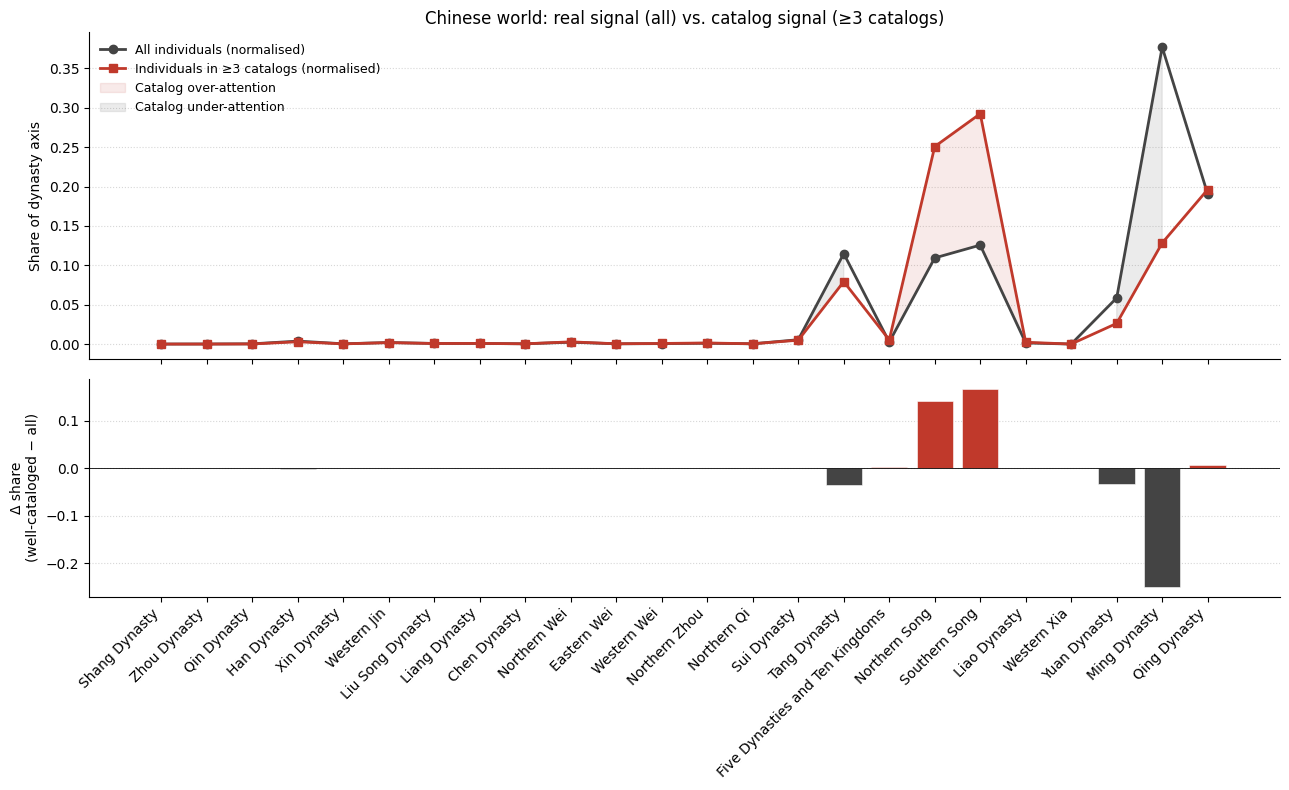

In [9]:
total_norm = trend['total'] / trend['total'].sum()
well_norm = trend['well_cataloged'] / trend['well_cataloged'].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 2]})

x = np.arange(len(DYNASTIES))
ax1.plot(x, total_norm.values, marker='o', linewidth=2, color='#444',
         label='All individuals (normalised)')
ax1.plot(x, well_norm.values, marker='s', linewidth=2, color='#c0392b',
         label='Individuals in ≥3 catalogs (normalised)')
ax1.fill_between(x, total_norm.values, well_norm.values,
                 where=well_norm.values > total_norm.values,
                 color='#c0392b', alpha=0.10, label='Catalog over-attention')
ax1.fill_between(x, total_norm.values, well_norm.values,
                 where=well_norm.values < total_norm.values,
                 color='#444', alpha=0.10, label='Catalog under-attention')
ax1.set_ylabel('Share of dynasty axis')
ax1.set_title('Chinese world: real signal (all) vs. catalog signal (≥3 catalogs)')
ax1.grid(axis='y', linestyle=':', alpha=0.5)
ax1.set_axisbelow(True)
for spine in ('top', 'right'):
    ax1.spines[spine].set_visible(False)
ax1.legend(frameon=False, fontsize=9, loc='upper left')

diff = (well_norm - total_norm).values
colors_diff = ['#c0392b' if d > 0 else '#444' for d in diff]
ax2.bar(x, diff, color=colors_diff, edgecolor='white', linewidth=0.4)
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_ylabel('Δ share\n(well-cataloged − all)')
ax2.set_xticks(x)
ax2.set_xticklabels(DYNASTIES, rotation=45, ha='right')
ax2.grid(axis='y', linestyle=':', alpha=0.5)
ax2.set_axisbelow(True)
for spine in ('top', 'right'):
    ax2.spines[spine].set_visible(False)

fig.tight_layout()
out2 = PLOTS_DIR / 'chinese_dynasties_real_vs_catalog.png'
fig.savefig(out2, dpi=200, bbox_inches='tight')
print('saved', out2)
plt.show()

## 6. Are some catalogs specialised on a single dynasty?

A catalog can artificially inflate one dynasty's headcount if its scope is focused on that period (e.g., a Tang-poetry index, a Ming-officials register). To detect this we compute, for every catalog × dynasty pair, a **focus index**:

$$\text{focus}(c, d) = \log_2\!\left(\frac{\text{share of catalog } c\text{'s entries at dynasty } d}{\text{share of all individuals at dynasty } d}\right)$$

Read it as a lift: `0` = the catalog distributes its attention exactly like the overall population; `+2` = ×4 over-representation at that dynasty; `−2` = ×4 under-representation. Catalogs with one big positive cell and small everywhere else are **specialised** and likely inflate that dynasty's count beyond what a generalist catalog would record.

In [ ]:
# Catalog × dynasty matrix of distinct individuals (kept in pandas — heatmap below
# uses 2-D arithmetic, .idxmax, .div(axis=…), and .loc indexing).
matrix = (
    id_counts.to_pandas()
    .pivot(index='identifier', columns='dynasty', values='n_individuals')
    .reindex(columns=DYNASTIES)
    .fillna(0)
)

# Keep catalogs with a meaningful presence in the Chinese world
catalog_totals = matrix.sum(axis=1)
matrix = matrix.loc[catalog_totals >= 30]
catalog_totals = matrix.sum(axis=1)

# Reference distribution = how all Chinese-dynasty individuals split across dynasties
overall = trend['total'] / trend['total'].sum()

share_by_catalog = matrix.div(catalog_totals, axis=0)
focus = np.log2((share_by_catalog + 1e-6) / (overall + 1e-6))

# Concentration: fraction of a catalog's entries falling in its single most
# represented dynasty (Herfindahl-style top-1 share). Higher = more specialised.
top_share = share_by_catalog.max(axis=1)
top_dynasty = share_by_catalog.idxmax(axis=1)
hhi = (share_by_catalog ** 2).sum(axis=1)

specialisation = pd.DataFrame({
    'total_individuals': catalog_totals.astype(int),
    'top_dynasty': top_dynasty,
    'top_share': top_share.round(3),
    'hhi': hhi.round(3),
}).sort_values('top_share', ascending=False)
specialisation.head(20)

saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/dynasty_plots/chinese_dynasties_catalog_focus_heatmap.png


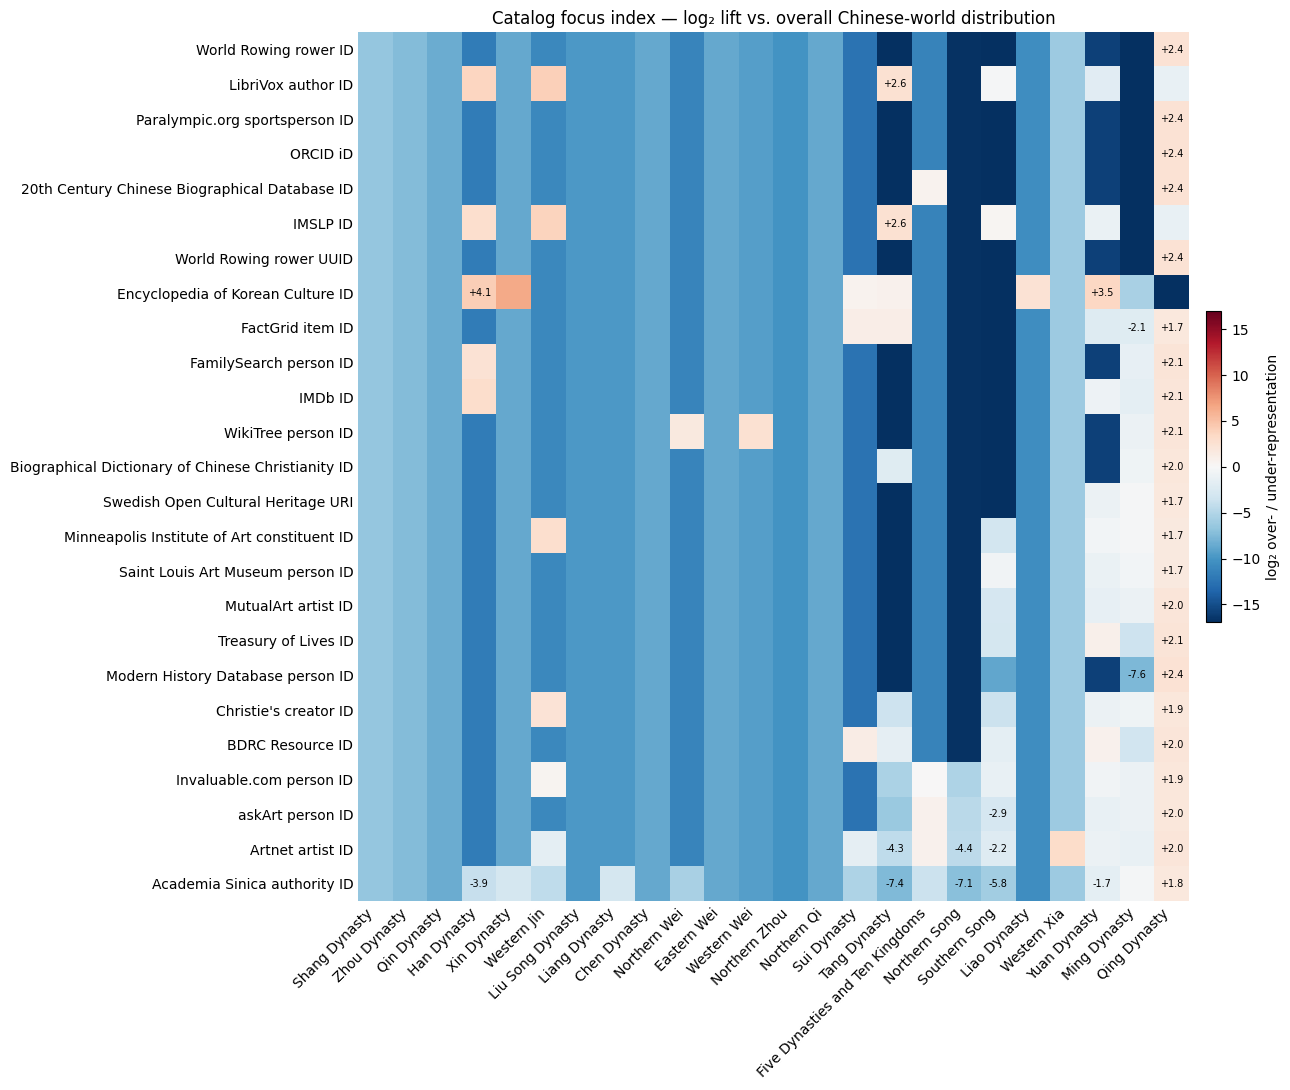

In [11]:
# Heatmap of focus index for the catalogs with the strongest dynasty-specific bias
top_catalogs = specialisation.sort_values('hhi', ascending=False).head(25).index
heat = focus.loc[top_catalogs]
heat = heat.loc[heat.abs().max(axis=1).sort_values(ascending=False).index]

vmax = float(np.nanpercentile(np.abs(heat.values), 98))
fig, ax = plt.subplots(figsize=(13, 0.38 * len(heat) + 1.5))
im = ax.imshow(heat.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(DYNASTIES)))
ax.set_xticklabels(DYNASTIES, rotation=45, ha='right')
ax.set_yticks(np.arange(len(heat)))
ax.set_yticklabels(heat.index)
ax.set_title('Catalog focus index — log₂ lift vs. overall Chinese-world distribution')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.018, pad=0.02)
cbar.set_label('log₂ over- / under-representation')

# Annotate the strongest cells
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if abs(v) >= 1.5 and matrix.loc[heat.index[i], DYNASTIES[j]] >= 5:
            ax.text(j, i, f'{v:+.1f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(v) > vmax * 0.6 else 'black')

fig.tight_layout()
out3 = PLOTS_DIR / 'chinese_dynasties_catalog_focus_heatmap.png'
fig.savefig(out3, dpi=200, bbox_inches='tight')
print('saved', out3)
plt.show()

### Per-dynasty catalog mix (column-normalised)

The previous heatmap normalises rows (each catalog vs. its own footprint). Here we normalise **columns**: for every dynasty, what share of the identifier rows comes from each catalog? Each column sums to 100 %, so we can read off "in dynasty X, the dominant catalogs are A (40 %), B (25 %), …".

saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/dynasty_plots/chinese_dynasties_catalog_mix_columnnorm.png


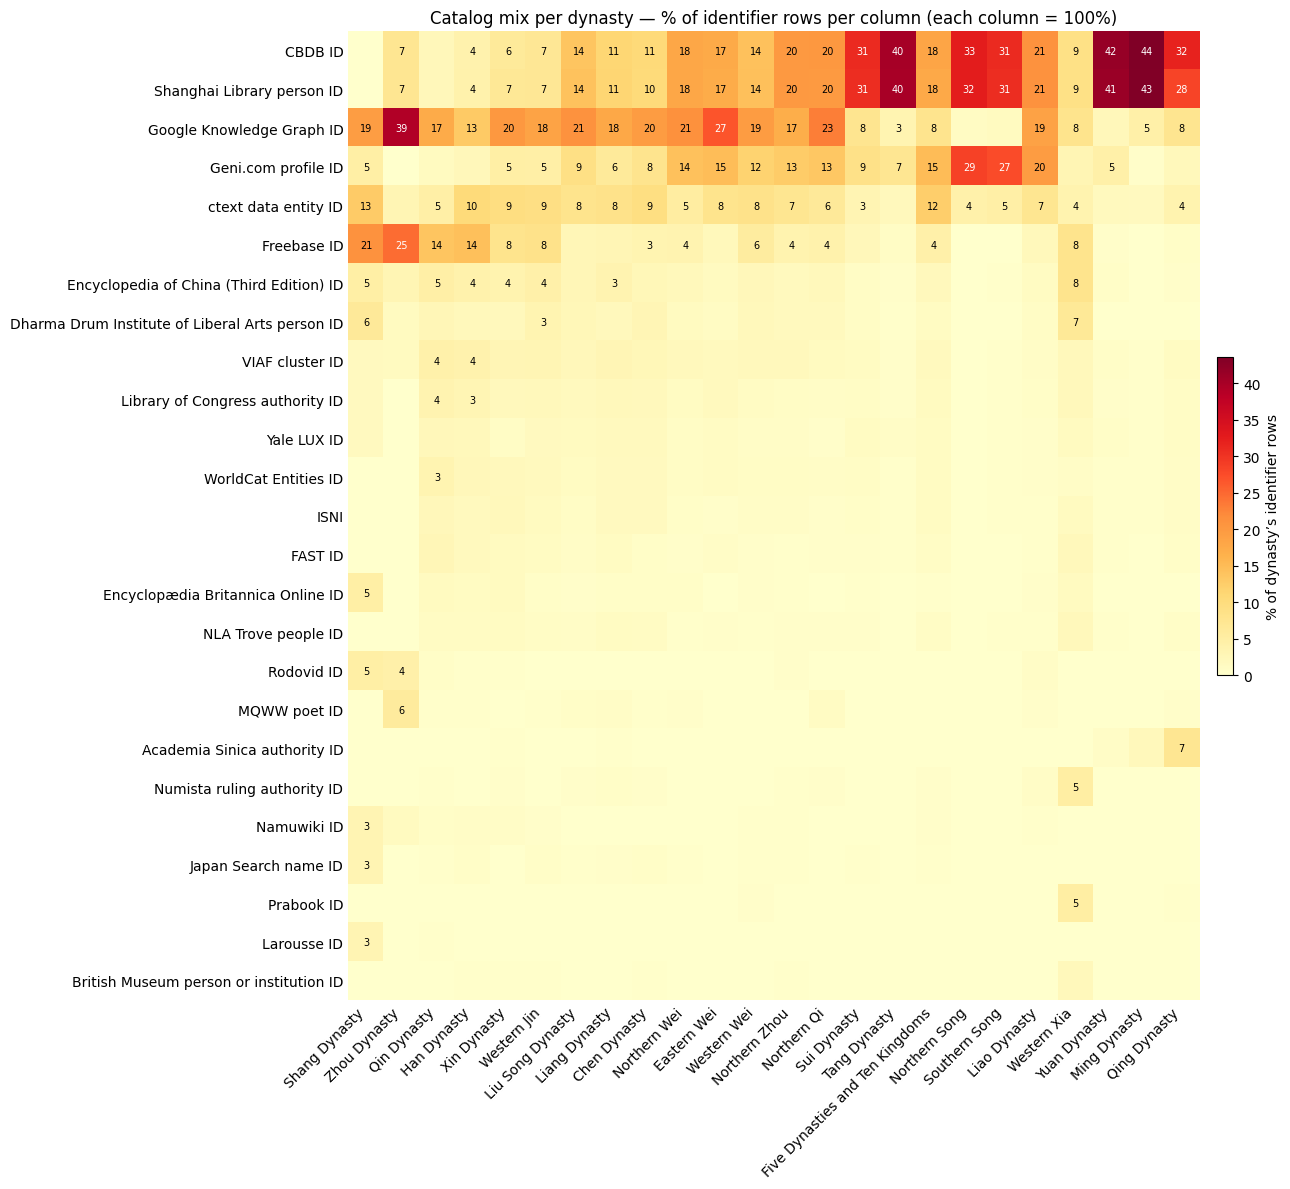

In [12]:
# Column-normalise the catalog × dynasty matrix: each column = 100 %.
col_share = matrix.div(matrix.sum(axis=0).replace(0, np.nan), axis=1).fillna(0) * 100

# Keep catalogs that ever reach a meaningful share in at least one dynasty.
TOP_CATALOG_LIMIT = 25
keep = col_share.max(axis=1).sort_values(ascending=False).head(TOP_CATALOG_LIMIT).index
col_share_top = col_share.loc[keep]

# Sort rows by overall (mean) share so dominant generalists go to the top.
row_order = col_share_top.mean(axis=1).sort_values(ascending=False).index
col_share_top = col_share_top.loc[row_order]

fig, ax = plt.subplots(figsize=(13, 0.42 * len(col_share_top) + 1.5))
im = ax.imshow(col_share_top.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=float(col_share_top.values.max()))

ax.set_xticks(np.arange(len(DYNASTIES)))
ax.set_xticklabels(DYNASTIES, rotation=45, ha='right')
ax.set_yticks(np.arange(len(col_share_top)))
ax.set_yticklabels(col_share_top.index)
ax.set_title('Catalog mix per dynasty — % of identifier rows per column (each column = 100%)')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.018, pad=0.02)
cbar.set_label('% of dynasty’s identifier rows')

# Annotate cells worth reading
threshold = max(3.0, np.nanpercentile(col_share_top.values, 70))
for i in range(col_share_top.shape[0]):
    for j in range(col_share_top.shape[1]):
        v = col_share_top.values[i, j]
        if v >= threshold:
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                    color='white' if v > col_share_top.values.max() * 0.55 else 'black')

fig.tight_layout()
out5 = PLOTS_DIR / 'chinese_dynasties_catalog_mix_columnnorm.png'
fig.savefig(out5, dpi=200, bbox_inches='tight')
print('saved', out5)
plt.show()

### How much of each dynasty's coverage is driven by specialised catalogs?

We tag a catalog as **specialised** when ≥ 60 % of its Chinese-world entries fall into a single dynasty. Then for every dynasty we measure how many individuals it would lose if those specialised catalogs were removed (i.e., individuals whose entire identifier footprint comes from specialised catalogs).

In [ ]:
SPECIALISED_THRESHOLD = 0.60
specialised_catalogs = specialisation[specialisation['top_share'] >= SPECIALISED_THRESHOLD].index.tolist()
print(f'{len(specialised_catalogs)} catalogs flagged as specialised (top-share ≥ {SPECIALISED_THRESHOLD}):')
for c in specialised_catalogs:
    info = specialisation.loc[c]
    print(f'  - {c}: {info["top_share"]*100:.0f}% on {info["top_dynasty"]} (n={info["total_individuals"]})')

ids_subset = ids_subset.with_columns(
    pl.col('identifier_name').is_in(specialised_catalogs).alias('is_specialised')
)

per_indiv = (
    ids_subset.group_by('wikidata_id')
    .agg([
        pl.col('is_specialised').sum().alias('sum'),
        pl.len().alias('count'),
    ])
)
only_specialised = set(
    per_indiv.filter((pl.col('sum') > 0) & (pl.col('sum') == pl.col('count')))['wikidata_id'].to_list()
)
ic_long = ic_long.with_columns(pl.col('wikidata_id').is_in(only_specialised).alias('only_specialised'))

decomp_pl = (
    ic_long.group_by('polity')
    .agg([
        pl.col('wikidata_id').n_unique().alias('total'),
        pl.col('only_specialised').sum().alias('only_via_specialised'),
    ])
)
decomp = (
    pl.DataFrame({'polity': DYNASTIES})
    .join(decomp_pl, on='polity', how='left')
    .with_columns([pl.col('total').fill_null(0), pl.col('only_via_specialised').fill_null(0)])
    .to_pandas()
    .set_index('polity')[['total', 'only_via_specialised']]
    .astype(int)
)
decomp['generalist_only'] = decomp['total'] - decomp['only_via_specialised']
decomp['inflation_share'] = decomp['only_via_specialised'] / decomp['total'].replace(0, np.nan)
decomp

saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/dynasty_plots/chinese_dynasties_specialist_vs_generalist.png


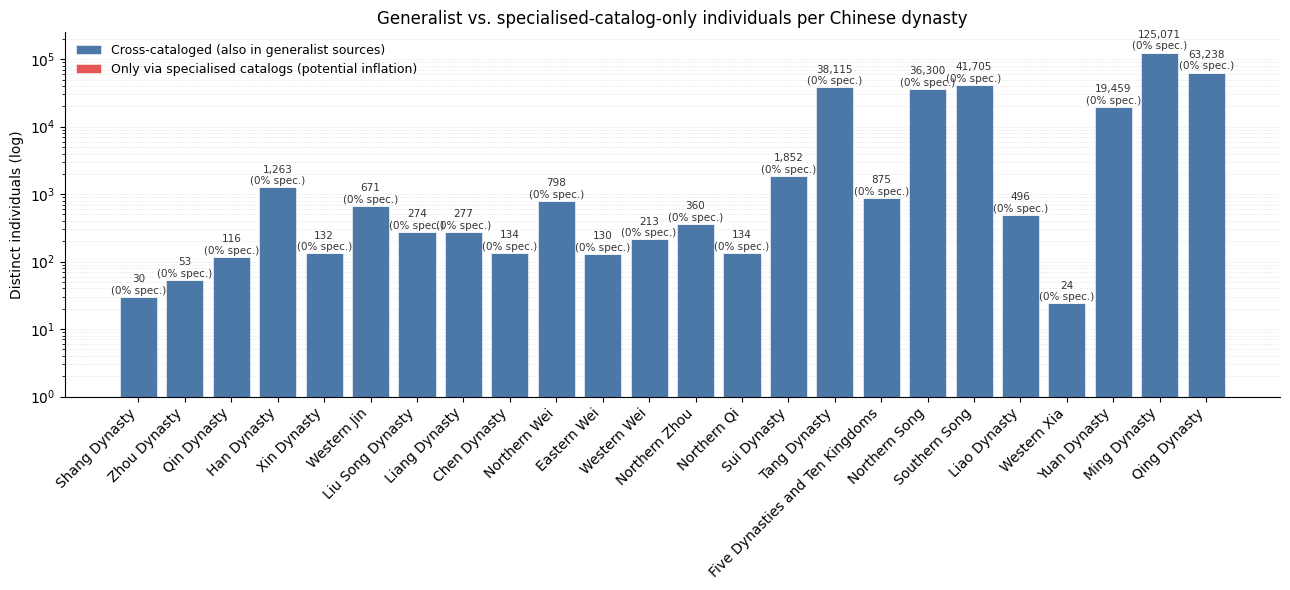

In [14]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(DYNASTIES))

ax.bar(x, decomp['generalist_only'].values, color='#4c78a8',
       edgecolor='white', linewidth=0.4, label='Cross-cataloged (also in generalist sources)')
ax.bar(x, decomp['only_via_specialised'].values, bottom=decomp['generalist_only'].values,
       color='#e45756', edgecolor='white', linewidth=0.4,
       label='Only via specialised catalogs (potential inflation)')

for xi, total, infl in zip(x, decomp['total'].values, decomp['inflation_share'].values):
    if total > 0:
        ax.text(xi, total * 1.04,
                f'{int(total):,}\n({infl*100:.0f}% spec.)' if not np.isnan(infl) else f'{int(total):,}',
                ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_yscale('log')
ymin = max(1, decomp[decomp > 0].min().min() * 0.5)
ax.set_ylim(ymin, decomp['total'].max() * 2)
ax.set_xticks(x)
ax.set_xticklabels(DYNASTIES, rotation=45, ha='right')
ax.set_ylabel('Distinct individuals (log)')
ax.set_title('Generalist vs. specialised-catalog-only individuals per Chinese dynasty')
ax.grid(axis='y', which='both', linestyle=':', linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc='upper left')

fig.tight_layout()
out4 = PLOTS_DIR / 'chinese_dynasties_specialist_vs_generalist.png'
fig.savefig(out4, dpi=200, bbox_inches='tight')
print('saved', out4)
plt.show()